# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [5]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [6]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

In [30]:
from sklearn.model_selection import GroupShuffleSplit
grupos = df_a["latitude"].round(1).astype(str) + "_" + df_a["longitude"].round(1).astype(str)
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED).split(df_a, groups=grupos))
rf_g = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1).fit(X_a.iloc[tr], y_a.iloc[tr])
p_g = rf_g.predict(X_a.iloc[te])
print("Random Forest com split por região (0,1°):",
      f"Accuracy={accuracy_score(y_a.iloc[te], p_g):.4f}  F1 macro={f1_score(y_a.iloc[te], p_g, average='macro'):.4f}")

Random Forest com split por região (0,1°): Accuracy=0.9428  F1 macro=0.9413


# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [7]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [8]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [9]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [10]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### Imports da análise e configuração geral

Bibliotecas de análise, gráficos e ML (acrescentadas por mim; o notebook de apoio só traz a consulta às APIs). A semente `SEED = 42` é usada em **todas** as divisões e modelos, para os resultados serem reproduzíveis.

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)

SEED = 42
os.makedirs("figuras", exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

### Exploração dos dados — classificação

Carrego o CSV gerado e confiro tamanho, tipos, valores ausentes, contagem por classe e distribuição das entradas.

In [12]:
df_a = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Linhas x colunas:", df_a.shape)
print()
print(df_a.dtypes)
print()
print("Valores ausentes por coluna:")
print(df_a.isna().sum())
print()
print("Exemplos por classe:")
print(df_a["fonte"].value_counts())
print()
print("Proporção por classe:")
print(df_a["fonte"].value_counts(normalize=True).round(3))
df_a.describe()

Linhas x colunas: (3876, 4)

potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Exemplos por classe:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

Proporção por classe:
fonte
Hidráulica   0.3810
Solar        0.3100
Eólica       0.3100
Name: proportion, dtype: float64


,potencia_kw,latitude,longitude
count,"3,876.0000","3,876.0000","3,876.0000"
mean,"42,014.6815",-12.6940,-46.1583
std,"301,636.5878",9.5005,8.3575
min,0.1600,-33.7228,-69.9414
25%,440.0000,-21.1421,-52.5618
50%,"12,680.0000",-10.4695,-47.3937
75%,"30,000.0000",-4.1278,-41.2800
max,"11,233,100.0000",3.8314,0.0000


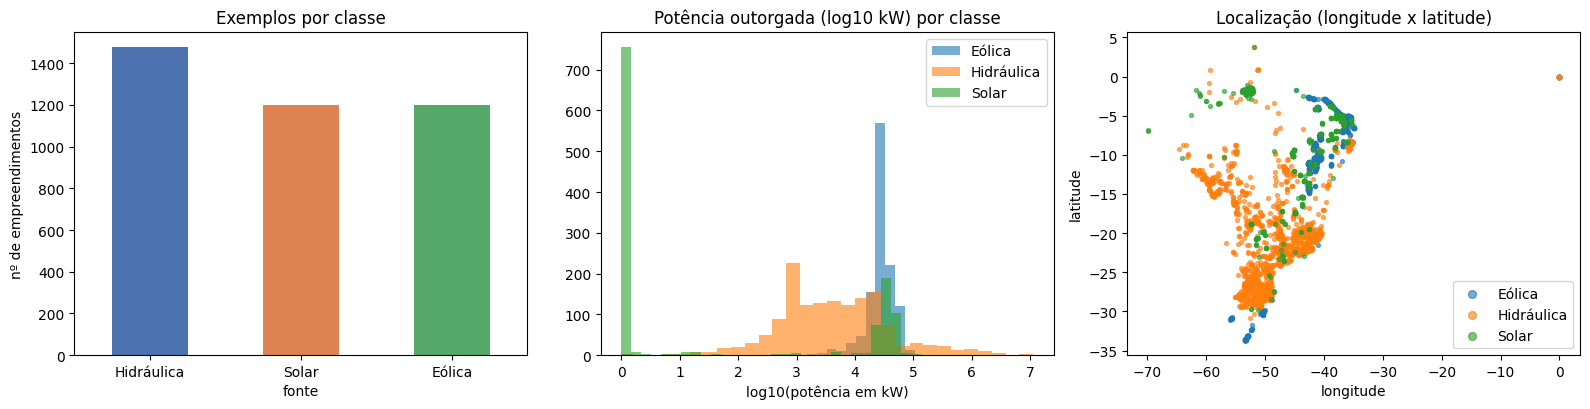

Mediana da potência (kW) por classe:
fonte
Eólica       29,600.0000
Hidráulica    4,000.0000
Solar             1.0000
Name: potencia_kw, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) contagem por classe
df_a["fonte"].value_counts().plot(kind="bar", ax=axes[0], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("Exemplos por classe")
axes[0].set_ylabel("nº de empreendimentos")
axes[0].tick_params(axis="x", rotation=0)

# (b) potência (escala log) por classe
for fonte, g in df_a.groupby("fonte"):
    axes[1].hist(np.log10(g["potencia_kw"].clip(lower=1)), bins=30, alpha=0.6, label=fonte)
axes[1].set_title("Potência outorgada (log10 kW) por classe")
axes[1].set_xlabel("log10(potência em kW)")
axes[1].legend()

# (c) mapa simples lat x lon
for fonte, g in df_a.groupby("fonte"):
    axes[2].scatter(g["longitude"], g["latitude"], s=8, alpha=0.6, label=fonte)
axes[2].set_title("Localização (longitude x latitude)")
axes[2].set_xlabel("longitude"); axes[2].set_ylabel("latitude")
axes[2].legend(markerscale=2)

plt.tight_layout()
plt.savefig("figuras/t1_exploracao.png", dpi=130)
plt.show()

print("Mediana da potência (kW) por classe:")
print(df_a.groupby("fonte")["potencia_kw"].median())

**Leitura da exploração.**

- O CSV vem de uma consulta com **limite por sigla** (1200 linhas por tipo), então a proporção entre classes reflete essa consulta e **não** a participação de cada fonte na matriz energética brasileira.
- A classe *Hidráulica* junta três siglas (`UHE`, `PCH`, `CGH`), o que a torna mais heterogênea em potência (de centenas de kW a milhares de MW).
- A potência é muito assimétrica (poucos empreendimentos enormes), por isso uso escala logarítmica só no gráfico; nos modelos, a padronização cuida da escala para os algoritmos sensíveis a ela.
- A localização carrega informação: cerca de 89% das eólicas e 90% das solares acima de 1 MW estão no Nordeste, enquanto a solar de 1 kW (maioria das solares do CSV) e a hidráulica se espalham pelo país. Há sobreposição regional entre solar e eólica de grande porte.

### Definição de X, y e divisão treino/teste (estratificada)

- **X:** `potencia_kw`, `latitude`, `longitude` (as três entradas numéricas).
- **y:** `fonte` (Solar, Eólica, Hidráulica).
- Divisão **80% treino / 20% teste**, **estratificada** por `fonte`, com `random_state=42`. As três classificações usam exatamente esta mesma divisão.
- A padronização (`StandardScaler`) fica dentro de um `Pipeline`, portanto é ajustada **somente com o treino**; o teste apenas é transformado.

In [14]:
X_a = df_a[["potencia_kw", "latitude", "longitude"]]
y_a = df_a["fonte"]

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    X_a, y_a, test_size=0.20, stratify=y_a, random_state=SEED)

print("Treino:", Xa_tr.shape, "| Teste:", Xa_te.shape)
print()
print("Classes no treino:"); print(ya_tr.value_counts())
print("Classes no teste:");  print(ya_te.value_counts())

Treino: (3100, 3) | Teste: (776, 3)

Classes no treino:
fonte
Hidráulica    1180
Solar          960
Eólica         960
Name: count, dtype: int64
Classes no teste:
fonte
Hidráulica    296
Solar         240
Eólica        240
Name: count, dtype: int64


### Três classificadores

| Algoritmo | Por que foi escolhido | Padronização |
|---|---|---|
| **Regressão Logística** (multinomial) | Modelo linear, simples, serve de linha de base. Fronteiras lineares tendem a limitar o desempenho aqui. | Sim (no pipeline) |
| **KNN** (k = 7) | Baseado em vizinhança: bom quando a localização agrupa as fontes. Usa distâncias, então **exige** padronização. | Sim (no pipeline) |
| **Random Forest** (300 árvores) | Captura relações não lineares e interações entre potência e localização; não depende de escala. | Não precisa |

Todos são treinados em `Xa_tr, ya_tr` e avaliados em `Xa_te, ya_te`. Nenhum hiperparâmetro foi ajustado com o teste.

In [15]:
classificadores = {
    "Regressão Logística": make_pipeline(StandardScaler(),
                                          LogisticRegression(max_iter=2000, random_state=SEED)),
    "KNN (k=7)":           make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
}
classes = sorted(y_a.unique())          # ordem fixa para as matrizes de confusão

resultados_a, previsoes_a = [], {}
for nome, modelo in classificadores.items():
    modelo.fit(Xa_tr, ya_tr)
    pred = modelo.predict(Xa_te)
    previsoes_a[nome] = pred
    resultados_a.append({
        "Algoritmo": nome,
        "Accuracy":            accuracy_score(ya_te, pred),
        "Precision (macro)":   precision_score(ya_te, pred, average="macro", zero_division=0),
        "Recall (macro)":      recall_score(ya_te, pred, average="macro", zero_division=0),
        "F1 (macro)":          f1_score(ya_te, pred, average="macro", zero_division=0),
        "F1 (weighted)":       f1_score(ya_te, pred, average="weighted", zero_division=0),
    })

tabela_a = pd.DataFrame(resultados_a).set_index("Algoritmo")
print("Avaliação: 20% de teste estratificado, random_state=42, mesmas divisões para os 3 modelos.")
print("Precision/Recall/F1 por média MACRO (média simples das 3 classes); F1 weighted incluído como referência.")
tabela_a

Avaliação: 20% de teste estratificado, random_state=42, mesmas divisões para os 3 modelos.
Precision/Recall/F1 por média MACRO (média simples das 3 classes); F1 weighted incluído como referência.


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Algoritmo,,,,,
Regressão Logística,0.8247,0.8282,0.8214,0.8197,0.8233
KNN (k=7),0.9652,0.9668,0.9633,0.9647,0.9651
Random Forest,0.9755,0.9769,0.9741,0.9753,0.9755


**Média usada:** `macro` para Precision, Recall e F1, isto é, a média simples entre as três classes, sem ponderar pelo tamanho. Assim uma classe pequena ou difícil pesa tanto quanto as demais. O `F1 weighted` aparece como referência (pondera pelo nº de exemplos de cada classe).

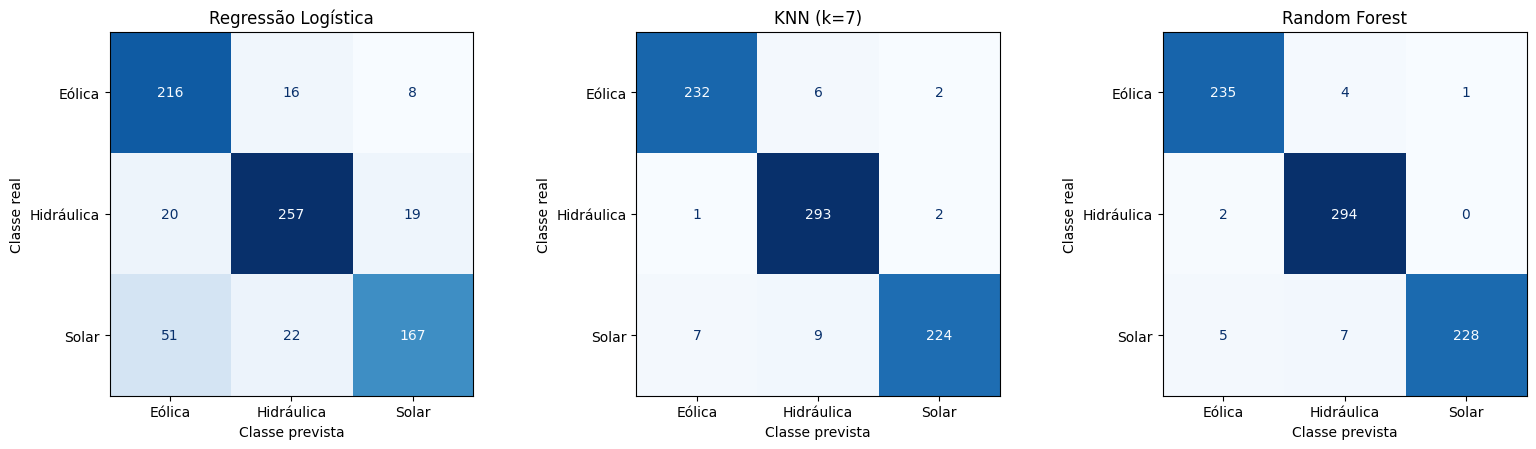

Melhor classificador por F1 macro: Random Forest
              precision    recall  f1-score   support

      Eólica       0.97      0.98      0.98       240
  Hidráulica       0.96      0.99      0.98       296
       Solar       1.00      0.95      0.97       240

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.98       776
weighted avg       0.98      0.98      0.98       776



In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (nome, pred) in zip(axes, previsoes_a.items()):
    cm = confusion_matrix(ya_te, pred, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nome)
    ax.set_xlabel("Classe prevista"); ax.set_ylabel("Classe real")
plt.tight_layout()
plt.savefig("figuras/t1_matrizes_confusao.png", dpi=130)
plt.show()

# Relatório por classe do melhor modelo (F1 macro)
melhor_a = tabela_a["F1 (macro)"].idxmax()
print("Melhor classificador por F1 macro:", melhor_a)
from sklearn.metrics import classification_report
print(classification_report(ya_te, previsoes_a[melhor_a], labels=classes, zero_division=0))

In [17]:
# Quais classes mais se confundem no melhor modelo? (erros fora da diagonal)
cm = confusion_matrix(ya_te, previsoes_a[melhor_a], labels=classes)
erros = []
for i, real in enumerate(classes):
    for j, prev in enumerate(classes):
        if i != j:
            erros.append((cm[i, j], real, prev, cm[i, j] / cm[i].sum()))
erros.sort(reverse=True)
print(f"Confusões mais frequentes em {melhor_a}:")
for n, real, prev, frac in erros:
    print(f"  {real:>10} classificada como {prev:<10}: {n:3d} casos ({frac:.1%} da classe real)")

Confusões mais frequentes em Random Forest:
       Solar classificada como Hidráulica:   7 casos (2.9% da classe real)
       Solar classificada como Eólica    :   5 casos (2.1% da classe real)
      Eólica classificada como Hidráulica:   4 casos (1.7% da classe real)
  Hidráulica classificada como Eólica    :   2 casos (0.7% da classe real)
      Eólica classificada como Solar     :   1 casos (0.4% da classe real)
  Hidráulica classificada como Solar     :   0 casos (0.0% da classe real)


### Interpretação — classificação

- **Modelo escolhido: Random Forest** (Accuracy 0,9755; F1 macro 0,9753), seguido do KNN (0,9652 / 0,9647). A Regressão Logística ficou bem abaixo (0,8247 / 0,8197): as fronteiras lineares não separam bem as classes, principalmente porque a potência solar é bimodal (a maioria das linhas tem 1 kW, e outra parte fica na casa de dezenas de MW). Os modelos não lineares combinam potência e localização e não sofrem com isso.
- **A potência é muito informativa neste cadastro.** Medianas: Solar 1 kW, Hidráulica 4.000 kW, Eólica 29.600 kW; 62,7% das linhas de Solar têm exatamente 1 kW, o que indica muitos registros de pequeno porte/valor padrão no cadastro. Por isso o desempenho alto reflete também características do cadastro, não só uma regra física.
- **Classes confundidas.** No Random Forest os erros são poucos e se concentram em **Solar** (recall 0,95): 7 solares classificadas como Hidráulica e 5 como Eólica; Eólica → Hidráulica teve 4 casos. Na Regressão Logística a maior confusão é Solar → Eólica (51 casos, 21% das solares). As solares de grande porte (dezenas de MW) se parecem com eólicas e hidráulicas em potência, e várias ficam no Nordeste, o que explica o resíduo de erro.
- **Limitações de prever a fonte só com potência e localização.**
  1. Não há informação sobre o recurso natural local (irradiação, vento, vazão) nem sobre bacia hidrográfica ou relevo.
  2. As coordenadas são aproximadas e o cadastro inclui empreendimentos em **diferentes fases**.
  3. A classe *Hidráulica* junta UHE, PCH e CGH, portes muito diferentes.
  4. A consulta limita 1200 linhas por tipo, então as proporções **não** representam a matriz energética brasileira.
  5. O split aleatório deixa empreendimentos vizinhos (ou duplicados: 44 linhas são repetições exatas) em treino e teste, o que tende a **otimizar** o resultado do KNN e do Random Forest. Ao dividir por células espaciais de 0,1° (célula extra abaixo), o Random Forest cai de 0,9755 para cerca de 0,94 de accuracy: ainda bom, mas menos otimista.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
grupos = df_a["latitude"].round(1).astype(str) + "_" + df_a["longitude"].round(1).astype(str)
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED).split(df_a, groups=grupos))
rf_g = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1).fit(X_a.iloc[tr], y_a.iloc[tr])
p_g = rf_g.predict(X_a.iloc[te])
print("Random Forest com split por região (0,1°):",
      f"Accuracy={accuracy_score(y_a.iloc[te], p_g):.4f}  F1 macro={f1_score(y_a.iloc[te], p_g, average='macro'):.4f}")

Random Forest com split por região (0,1°): Accuracy=0.9428  F1 macro=0.9413


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [18]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [19]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [20]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [21]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### Exploração dos dados — regressão

Carrego o CSV horário de Petrolina, confiro colunas, ausentes e faço as visualizações. As linhas já estão em ordem cronológica.

In [22]:
df_m = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
df_m = df_m.sort_values("data_hora").reset_index(drop=True)      # garante a ordem temporal
print("Linhas x colunas:", df_m.shape)
print("Período:", df_m["data_hora"].min(), "->", df_m["data_hora"].max())
print()
print(df_m.dtypes)
print()
print("Valores ausentes por coluna:")
print(df_m.isna().sum())
df_m.describe()

Linhas x colunas: (1001, 7)
Período: 2025-04-01 07:00:00 -> 2025-06-30 17:00:00

data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,"1,001.0000","1,001.0000","1,001.0000","1,001.0000","1,001.0000","1,001.0000"
mean,2025-05-16 11:59:59.999999744,28.8859,50.5445,55.1089,15.4654,12.0000,472.8541
min,2025-04-01 07:00:00,19.5000,21.0000,0.0000,2.3000,7.0000,13.0000
25%,2025-04-23 15:00:00,26.3000,38.0000,19.0000,12.2000,9.0000,250.0000
50%,2025-05-16 12:00:00,29.1000,49.0000,54.0000,15.4000,12.0000,466.0000
75%,2025-06-08 09:00:00,31.7000,61.0000,98.0000,19.0000,15.0000,696.0000
max,2025-06-30 17:00:00,36.1000,95.0000,100.0000,30.1000,17.0000,"1,002.0000"
std,NaN,3.6565,15.9140,37.8515,4.9236,3.1639,256.3690


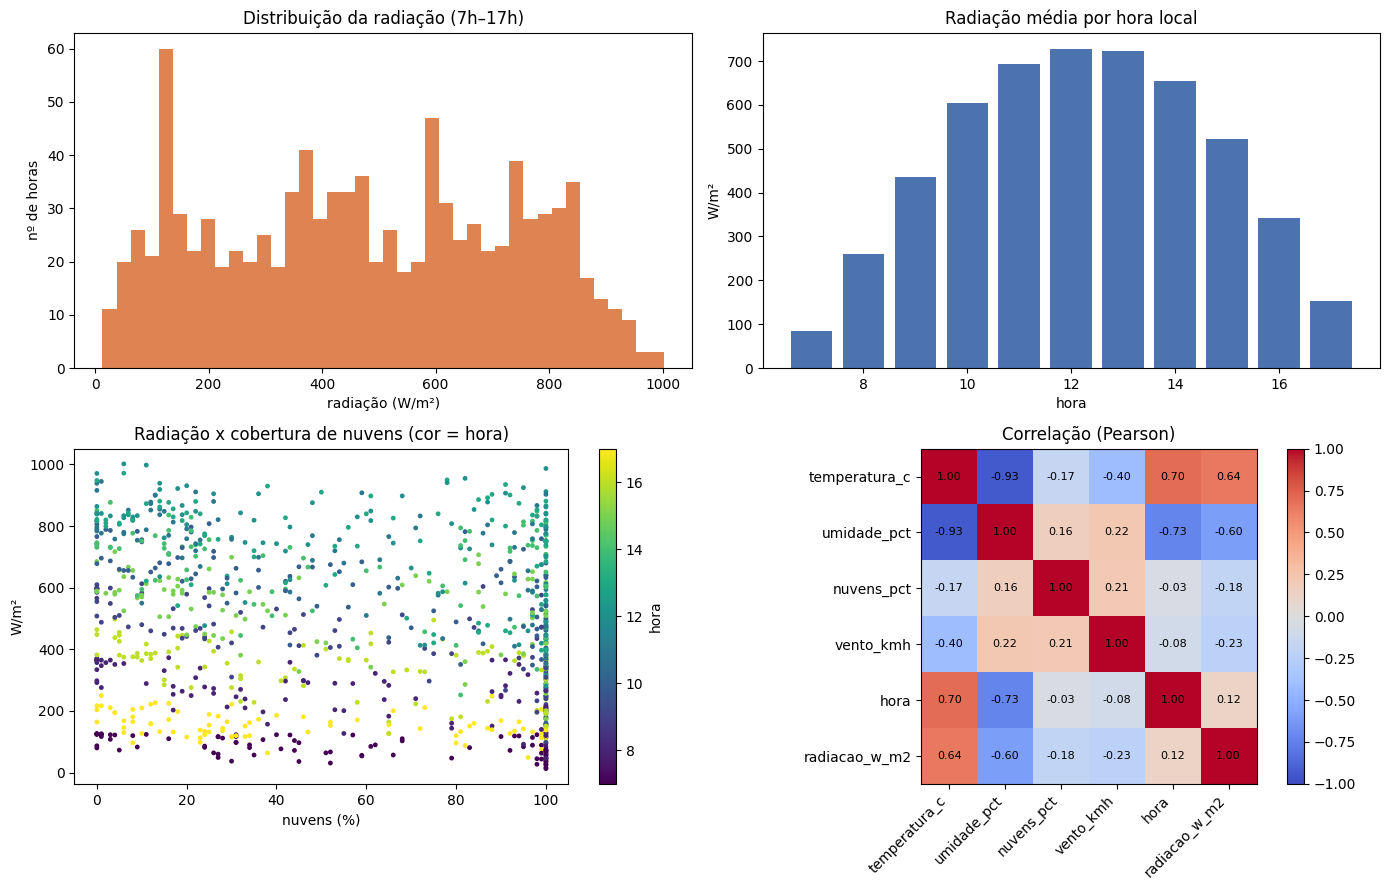

Correlação de cada entrada com a radiação:
umidade_pct     -0.5962
vento_kmh       -0.2294
nuvens_pct      -0.1802
hora             0.1201
temperatura_c    0.6427
Name: radiacao_w_m2, dtype: float64


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) distribuição do alvo
axes[0, 0].hist(df_m["radiacao_w_m2"], bins=40, color="#dd8452")
axes[0, 0].set_title("Distribuição da radiação (7h–17h)")
axes[0, 0].set_xlabel("radiação (W/m²)"); axes[0, 0].set_ylabel("nº de horas")

# (b) radiação média por hora do dia
media_hora = df_m.groupby("hora")["radiacao_w_m2"].mean()
axes[0, 1].bar(media_hora.index, media_hora.values, color="#4c72b0")
axes[0, 1].set_title("Radiação média por hora local")
axes[0, 1].set_xlabel("hora"); axes[0, 1].set_ylabel("W/m²")

# (c) radiação x nuvens
sc = axes[1, 0].scatter(df_m["nuvens_pct"], df_m["radiacao_w_m2"], c=df_m["hora"], s=6, cmap="viridis")
axes[1, 0].set_title("Radiação x cobertura de nuvens (cor = hora)")
axes[1, 0].set_xlabel("nuvens (%)"); axes[1, 0].set_ylabel("W/m²")
plt.colorbar(sc, ax=axes[1, 0], label="hora")

# (d) correlação entre variáveis
cols = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"]
corr = df_m[cols].corr()
im = axes[1, 1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(cols))); axes[1, 1].set_xticklabels(cols, rotation=45, ha="right")
axes[1, 1].set_yticks(range(len(cols))); axes[1, 1].set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        axes[1, 1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes[1, 1].set_title("Correlação (Pearson)")
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.savefig("figuras/t2_exploracao.png", dpi=130)
plt.show()
print("Correlação de cada entrada com a radiação:")
print(corr["radiacao_w_m2"].drop("radiacao_w_m2").sort_values())

**Leitura da exploração.**

- A radiação tem forma de "sino" ao longo do dia: sobe até perto do meio-dia e cai à tarde. Isso torna a **hora** uma variável muito informativa, e de forma **não linear** (o pico no meio do dia não é uma reta).
- Mais nuvens tendem a reduzir a radiação, mas o efeito depende da hora: às 7h e às 17h a radiação é baixa mesmo com céu limpo.
- Temperatura e umidade variam junto com o ciclo diário (temperatura sobe com o sol, umidade cai), então parte da correlação delas com a radiação vem da hora, não de uma relação causal direta.

### Definição de X, y e divisão temporal

- **X:** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
- **y:** `radiacao_w_m2`. Nenhuma coluna derivada dela entra em X, e `data_hora` serve só para ordenar.
- **Divisão temporal:** as **primeiras 80% das horas** treinam e as **últimas 20%** testam, **sem embaralhar**. Assim o teste simula prever um período futuro (meados/fim do período), o que é mais honesto para dados de série temporal do que uma divisão aleatória, que deixaria horas vizinhas em treino e teste.
- Os três regressores usam a mesma divisão; a padronização (quando usada) é ajustada só no treino.

In [24]:
cols_x = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_m = df_m[cols_x]
y_m = df_m["radiacao_w_m2"]

corte = int(len(df_m) * 0.80)
Xm_tr, Xm_te = X_m.iloc[:corte], X_m.iloc[corte:]
ym_tr, ym_te = y_m.iloc[:corte], y_m.iloc[corte:]
datas_te = df_m["data_hora"].iloc[corte:]

print(f"Treino: {len(Xm_tr)} horas ({df_m['data_hora'].iloc[0]} -> {df_m['data_hora'].iloc[corte-1]})")
print(f"Teste : {len(Xm_te)} horas ({df_m['data_hora'].iloc[corte]} -> {df_m['data_hora'].iloc[-1]})")

Treino: 800 horas (2025-04-01 07:00:00 -> 2025-06-12 14:00:00)
Teste : 201 horas (2025-06-12 15:00:00 -> 2025-06-30 17:00:00)


### Três regressores

| Algoritmo | Por que foi escolhido | Padronização |
|---|---|---|
| **Regressão Linear** | Linha de base interpretável. Não consegue representar o "sino" diário só com `hora` linear. | Sim (no pipeline) |
| **Random Forest Regressor** (300 árvores) | Captura não linearidades e interações hora × nuvens. | Não precisa |
| **Gradient Boosting Regressor** | Árvores sequenciais que corrigem erros anteriores; costuma ser muito competitivo em dados tabulares. | Não precisa |

Métricas: **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**, todas calculadas no conjunto de teste temporal.

In [25]:
regressores = {
    "Regressão Linear":  make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest":     RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}

resultados_m, previsoes_m = [], {}
for nome, modelo in regressores.items():
    modelo.fit(Xm_tr, ym_tr)
    pred = modelo.predict(Xm_te)
    previsoes_m[nome] = pred
    mse = mean_squared_error(ym_te, pred)
    resultados_m.append({
        "Algoritmo": nome,
        "MAE (W/m²)":    mean_absolute_error(ym_te, pred),
        "MSE ((W/m²)²)": mse,
        "RMSE (W/m²)":   np.sqrt(mse),
        "R²":            r2_score(ym_te, pred),
    })

tabela_m = pd.DataFrame(resultados_m).set_index("Algoritmo")
print("Avaliação: últimas 20% das horas (divisão temporal), mesmas divisões para os 3 modelos.")
tabela_m

Avaliação: últimas 20% das horas (divisão temporal), mesmas divisões para os 3 modelos.


,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Algoritmo,,,,
Regressão Linear,145.2049,"30,034.2011",173.3038,0.3598
Random Forest,66.3994,"7,210.0838",84.9122,0.8463
Gradient Boosting,67.0816,"7,444.7002",86.2827,0.8413


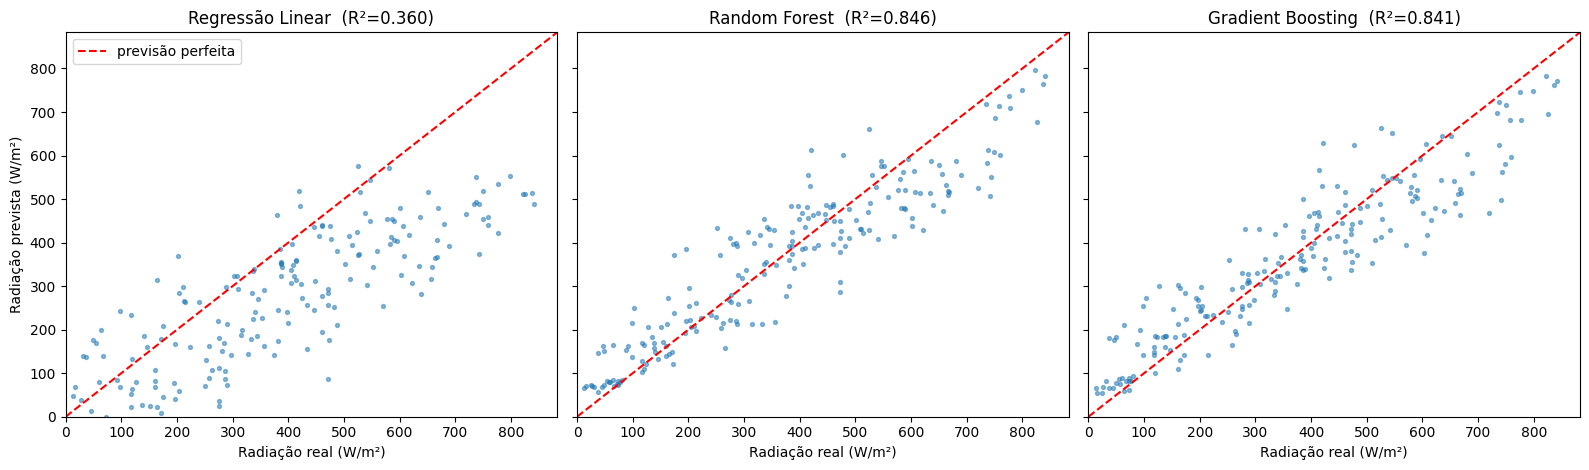

Melhor regressor por MAE: Random Forest


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
lim = [0, max(ym_te.max(), max(p.max() for p in previsoes_m.values())) * 1.05]
for ax, (nome, pred) in zip(axes, previsoes_m.items()):
    ax.scatter(ym_te, pred, s=8, alpha=0.5)
    ax.plot(lim, lim, "r--", label="previsão perfeita")
    ax.set_title(f"{nome}  (R²={r2_score(ym_te, pred):.3f})")
    ax.set_xlabel("Radiação real (W/m²)")
    ax.set_xlim(lim); ax.set_ylim(lim)
axes[0].set_ylabel("Radiação prevista (W/m²)")
axes[0].legend()
plt.tight_layout()
plt.savefig("figuras/t2_real_vs_previsto.png", dpi=130)
plt.show()

melhor_m = tabela_m["MAE (W/m²)"].idxmin()
print("Melhor regressor por MAE:", melhor_m)

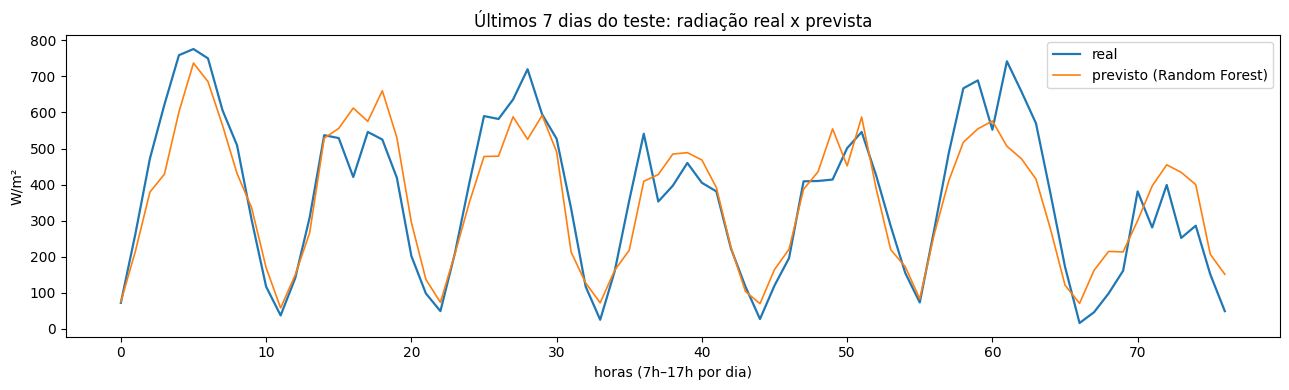

Erro absoluto médio por hora (W/m²):
hora
7    23.3000
8    34.2000
9    69.1000
10   94.5000
11   81.9000
12   76.7000
13   83.4000
14   90.8000
15   79.8000
16   58.7000
17   39.3000
Name: erro_abs, dtype: float64


In [27]:
# Série temporal: últimos 7 dias do teste, real x melhor modelo
n = 7 * 11                                  # 11 horas por dia
plt.figure(figsize=(13, 4))
plt.plot(range(n), ym_te.values[-n:], label="real", lw=1.6)
plt.plot(range(n), previsoes_m[melhor_m][-n:], label=f"previsto ({melhor_m})", lw=1.2)
plt.title("Últimos 7 dias do teste: radiação real x prevista")
plt.xlabel("horas (7h–17h por dia)"); plt.ylabel("W/m²")
plt.legend(); plt.tight_layout()
plt.savefig("figuras/t2_serie_teste.png", dpi=130)
plt.show()

# Erro médio por hora do dia (melhor modelo)
erro_hora = (pd.DataFrame({"hora": Xm_te["hora"].values,
                            "erro_abs": np.abs(ym_te.values - previsoes_m[melhor_m])})
             .groupby("hora")["erro_abs"].mean())
print("Erro absoluto médio por hora (W/m²):"); print(erro_hora.round(1))

Importância das entradas (Random Forest):
hora            0.4853
temperatura_c   0.2959
umidade_pct     0.1812
nuvens_pct      0.0216
vento_kmh       0.0160
dtype: float64


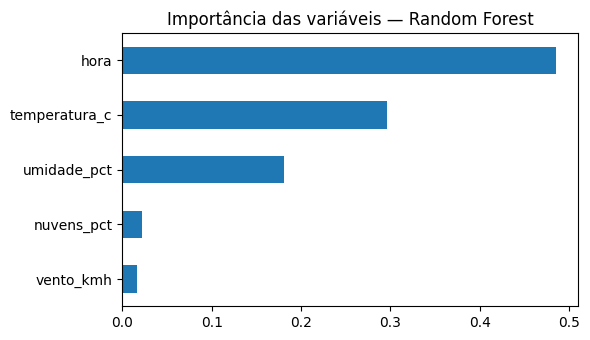


Random Forest COM hora : MAE=66.4  R²=0.846
Random Forest SEM hora : MAE=131.4  R²=0.337


In [28]:
# Importância das variáveis (Random Forest) — papel da hora
rf = regressores["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=cols_x).sort_values(ascending=False)
print("Importância das entradas (Random Forest):")
print(imp)
imp.sort_values().plot(kind="barh", title="Importância das variáveis — Random Forest", figsize=(6, 3.5))
plt.tight_layout(); plt.savefig("figuras/t2_importancia.png", dpi=130); plt.show()

# Teste rápido: o que muda sem a hora?
rf_sem_hora = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_sem_hora.fit(Xm_tr.drop(columns="hora"), ym_tr)
p = rf_sem_hora.predict(Xm_te.drop(columns="hora"))
print(f"\nRandom Forest COM hora : MAE={mean_absolute_error(ym_te, previsoes_m['Random Forest']):.1f}  R²={r2_score(ym_te, previsoes_m['Random Forest']):.3f}")
print(f"Random Forest SEM hora : MAE={mean_absolute_error(ym_te, p):.1f}  R²={r2_score(ym_te, p):.3f}")

### Interpretação — regressão

- **Comparação.** Random Forest (MAE 66,40 W/m²; MSE 7.210; R² 0,846) e Gradient Boosting (67,08; 7.445; 0,841) ficaram praticamente empatados e muito melhores que a Regressão Linear (145,20; 30.034; R² 0,360). A radiação segue um "sino" ao longo do dia, e um modelo linear em `hora` não representa isso; as árvores capturam a curva e interações entre variáveis.
- **Papel da hora.** É a variável mais importante do Random Forest (importância 0,49). Sem a hora, o Random Forest piora de MAE 66,4 / R² 0,846 para MAE 131,4 / R² 0,337. A hora codifica a posição do sol, que define o teto de radiação possível. Temperatura (0,30) e umidade (0,18) também carregam parte do ciclo diário.
- **Nuvens.** A correlação geral com a radiação é fraca (−0,18) porque a hora domina a variância; ao meio-dia ela sobe para −0,51. No Random Forest, a importância de `nuvens_pct` é pequena (0,02), provavelmente porque umidade e temperatura já capturam parte do efeito da nebulosidade.
- **Erros.** Ficam maiores no meio do dia (cerca de 70–95 W/m² entre 9h e 15h), onde os valores são mais altos, e menores nas bordas (23 W/m² às 7h, 39 W/m² às 17h).
- **Limitação da divisão temporal.** O teste (12/06 a 30/06/2025) tem radiação média menor que o treino (373 contra 498 W/m²), então há mudança de distribuição e o modelo, que só viu abril–meados de junho, não é validado para outras épocas do ano. Árvores também não extrapolam além do que viram no treino.
- **Radiação não é geração elétrica.** O alvo é radiação global horizontal estimada por modelos/reanálise, em W/m² (potência por área, média horária). A energia gerada por um sistema fotovoltaico (em kWh) depende também de inclinação e orientação dos painéis, eficiência dos módulos e do inversor, temperatura de operação, sombreamento e sujeira, perdas elétricas e potência instalada.

In [29]:
!zip -r saidas.zip aneel_classificacao_orange.csv meteo_regressao_orange.csv figuras
from google.colab import files
files.download("saidas.zip")

  adding: aneel_classificacao_orange.csv (deflated 70%)
  adding: meteo_regressao_orange.csv (deflated 73%)
  adding: figuras/ (stored 0%)
  adding: figuras/t2_exploracao.png (deflated 8%)
  adding: figuras/t1_exploracao.png (deflated 9%)
  adding: figuras/t1_matrizes_confusao.png (deflated 19%)
  adding: figuras/t2_serie_teste.png (deflated 3%)
  adding: figuras/t2_real_vs_previsto.png (deflated 9%)
  adding: figuras/t2_importancia.png (deflated 18%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)

# Conclusões gerais

- **Classificação (ANEEL):** Random Forest (Accuracy 0,9755; F1 macro 0,9753) > KNN (0,9652; 0,9647) > Regressão Logística (0,8247; 0,8197), com o mesmo split estratificado 80/20 (`random_state=42`) e médias macro. A potência é muito informativa neste cadastro, e os poucos erros do melhor modelo se concentram na classe Solar. O desempenho pode estar otimista por vizinhança espacial e por características do cadastro (muitas linhas solares com 1 kW).
- **Regressão (Open-Meteo):** Random Forest (MAE 66,40; R² 0,846) ≈ Gradient Boosting (67,08; 0,841) >> Regressão Linear (145,20; 0,360), com a mesma divisão temporal 80/20. A hora do dia é a variável mais importante; estimar radiação não equivale a prever geração elétrica.
- **Aviso:** os resultados dependem da resposta das APIs no momento da execução (o cadastro da ANEEL é atualizado continuamente), então os números podem variar entre execuções.